In [1]:
import jax.numpy as jnp
import numpy as np  # still used for file reading/parsing
from pathlib import Path
from project_utils import open_pickled_file, setup_matplotlib_styles
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
setup_matplotlib_styles()
colors = ['dodgerblue', 'coral', 'darkviolet', 'limegreen', 'mediumvioletred', 'teal']
sns.set_palette(colors)

path_figures = '/Users/amanda/Desktop/PhD/Tools/ceridwen/figs/neb'

In [16]:
ssp_path = '/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/spectra.csv'

spectrum = pd.read_csv(ssp_path)
spectrum

,wave,flux,flux_fnu
0,91.0,0.000000e+00,5.509815e-28
1,94.0,0.000000e+00,3.055043e-27
2,96.0,0.000000e+00,1.007758e-26
3,98.0,0.000000e+00,3.412729e-26
4,100.0,0.000000e+00,4.675545e-26
...,...,...,...
5989,96380000.0,9.195806e-27,7.847040e-10
5990,97270000.0,8.863818e-27,7.704081e-10
5991,98170000.0,8.543232e-27,7.563485e-10
5992,99080000.0,8.233655e-27,7.425177e-10


In [ ]:

class NebularModel:
    def __init__(self, isoc_type, cloudy_dust, sps_home, csp_lambda,
                 clight, mypi, smooth_velocity=True, nebnz=11, nebnage=10, nebnip=7, nebular_smooth_init=100.0):
        self.csp_lambda = jnp.asarray(csp_lambda)
        self.nspec = self.csp_lambda.size
        self.clight = clight
        self.mypi = mypi
        self.smooth_velocity = smooth_velocity
        self.nebular_smooth_init = nebular_smooth_init
        self.nebnz = nebnz
        self.nebnage = nebnage
        self.nebnip = nebnip

        # File paths
        suffix = 'WD' if cloudy_dust else 'ND'
        base = Path(sps_home) / 'nebular' / f'ZAU_{suffix}_{isoc_type}'
        self.cont_file = base.with_suffix('.cont')
        self.line_file = base.with_suffix('.lines')

        # Load data
        self._load_continuum()
        self._load_lines()
        self._compute_resolution_elements()
        self._build_gaussians()

    def _load_continuum(self):
        with open(self.cont_file, 'r') as f:
            f.readline()
            readlambneb = np.array([float(x) for x in f.readline().split()])
            nlam = len(readlambneb)

            lines = f.readlines()
            
            cont_cube = np.zeros((self.nspec, self.nebnz, self.nebnage, self.nebnip))
            logz_grid = np.zeros(self.nebnz)
            logu_grid = np.zeros(self.nebnip)
            age_grid = np.zeros(self.nebnage)

            idx = 0
            for i in range(self.nebnz):
                for j in range(self.nebnage):
                    for k in range(self.nebnip):
                        parts = [float(x) for x in lines[idx].split()]
                        logz_grid[i], age_grid[j], logu_grid[k] = parts[:3]
                        idx += 1
                        cont = np.array([float(x) for x in lines[idx].split()])
                        logcont = np.log10(cont + 10**-95)
                        cont_interp = np.interp(self.csp_lambda, readlambneb, logcont)
                        cont_cube[:, i, j, k] = cont_interp
                        idx += 1

            self.nebem_cont = jnp.asarray(cont_cube)
            self.nebem_logz = jnp.asarray(logz_grid)
            self.nebem_logu = jnp.asarray(logu_grid)
            self.nebem_age = jnp.log10(jnp.asarray(age_grid))

    def _load_lines(self):
        with open(self.line_file, 'r') as f:
            f.readline()
            self.nebem_line_pos = jnp.array([float(x) for x in f.readline().split()])
            self.nemline = self.nebem_line_pos.shape[0]
            line_cube = np.zeros((self.nemline, self.nebnz, self.nebnage, self.nebnip))

            for i in range(self.nebnz):
                for j in range(self.nebnage):
                    for k in range(self.nebnip):
                        f.readline()
                        linevals = np.array([float(x) for x in f.readline().split()])
                        line_cube[:, i, j, k] = np.log10(linevals + 10**-95)

            self.nebem_line = jnp.asarray(line_cube)

    def _compute_resolution_elements(self):
        neb_res = []
        for i in range(self.nemline):
            idx = int(jnp.clip(jnp.searchsorted(self.csp_lambda, self.nebem_line_pos[i]) - 1, 1, self.nspec - 2))
            dlam = self.csp_lambda[idx + 1] - self.csp_lambda[idx]
            neb_res.append(dlam)
        self.neb_res_min = jnp.asarray(neb_res)

    def _build_gaussians(self):
        profiles = []
        for i in range(self.nemline):
            if self.smooth_velocity:
                dlam = self.nebem_line_pos[i] * self.nebular_smooth_init / self.clight * 1e13
            else:
                dlam = self.nebular_smooth_init
            dlam = jnp.maximum(dlam, self.neb_res_min[i] * 2)

            prof = jnp.exp(-(self.csp_lambda - self.nebem_line_pos[i])**2 / (2 * dlam**2))
            prof /= (jnp.sqrt(2 * self.mypi) * dlam * self.clight * self.nebem_line_pos[i]**2)
            profiles.append(prof)
        self.gaussnebarr = jnp.stack(profiles, axis=-1)

    def evaluate(self, logZ, logU, logage, Q):
        """
        Return nebular spectrum on csp_lambda given logZ, logU, logage, and Q
        """
        def locate(x, grid):
            return jnp.clip(jnp.searchsorted(grid, x) - 1, 0, grid.size - 2)

        def trilinear_interp(cube, z1, dz, a1, da, u1, du):
            return (
                (1 - dz) * (1 - da) * (1 - du) * cube[:, z1,   a1,   u1] +
                (1 - dz) * (1 - da) * du       * cube[:, z1,   a1,   u1+1] +
                (1 - dz) * da       * (1 - du) * cube[:, z1,   a1+1, u1] +
                (1 - dz) * da       * du       * cube[:, z1,   a1+1, u1+1] +
                dz       * (1 - da) * (1 - du) * cube[:, z1+1, a1,   u1] +
                dz       * (1 - da) * du       * cube[:, z1+1, a1,   u1+1] +
                dz       * da       * (1 - du) * cube[:, z1+1, a1+1, u1] +
                dz       * da       * du       * cube[:, z1+1, a1+1, u1+1]
            )

        def trilinear_interp_lines(cube, z1, dz, a1, da, u1, du):
            return (
                (1 - dz) * (1 - da) * (1 - du) * cube[:, z1,   a1,   u1] +
                (1 - dz) * (1 - da) * du       * cube[:, z1,   a1,   u1+1] +
                (1 - dz) * da       * (1 - du) * cube[:, z1,   a1+1, u1] +
                (1 - dz) * da       * du       * cube[:, z1,   a1+1, u1+1] +
                dz       * (1 - da) * (1 - du) * cube[:, z1+1, a1,   u1] +
                dz       * (1 - da) * du       * cube[:, z1+1, a1,   u1+1] +
                dz       * da       * (1 - du) * cube[:, z1+1, a1+1, u1] +
                dz       * da       * du       * cube[:, z1+1, a1+1, u1+1]
            )

        z1 = locate(logZ, self.nebem_logz)
        dz = jnp.clip((logZ - self.nebem_logz[z1]) / (self.nebem_logz[z1 + 1] - self.nebem_logz[z1]), 0, 1)
        print(f'z1: {z1}, dz: {dz}')
        u1 = locate(logU, self.nebem_logu)
        du = jnp.clip((logU - self.nebem_logu[u1]) / (self.nebem_logu[u1 + 1] - self.nebem_logu[u1]), 0, 1)
        a1 = locate(logage, self.nebem_age)
        da = jnp.clip((logage - self.nebem_age[a1]) / (self.nebem_age[a1 + 1] - self.nebem_age[a1]), 0, 1)

        logcont = trilinear_interp(self.nebem_cont, z1, dz, a1, da, u1, du)
        print(f'logcont: {logcont}', len(logcont))
        print(Q, jnp.log10(Q))
        logQ = jnp.log(jnp.asarray(Q, dtype=jnp.float64)) / jnp.log(10.)
        cont_flux = 10 ** (logcont + logQ)
        print(f'cont_flux: {cont_flux}', len(cont_flux))

        loglines = trilinear_interp_lines(self.nebem_line, z1, dz, a1, da, u1, du)
        line_flux = 10 ** loglines * Q

        spec = cont_flux + jnp.dot(self.gaussnebarr, line_flux)
        return spec

In [73]:
from jax import numpy as jnp
from scipy.constants import c, pi

model = NebularModel(
    isoc_type="bpss",
    cloudy_dust=True,
    sps_home="/Users/amanda/Prospector/fsps",
    csp_lambda=spectrum['wave'],
    clight=c * 1e10,
    mypi=pi,
    nebular_smooth_init=100.0
)

spec = model.evaluate(logZ=-1.0, logU=-2.5, logage=jnp.log10(1e7), Q=1e3)

z1: 0, dz: 1.0
logcont: [-83.238144 -83.17012  -82.66857  ... -59.435097 -59.434624 -59.43415 ] 5994
1000.0 3.0
cont_flux: [0. 0. 0. ... 0. 0. 0.] 5994


/var/folders/vd/kv9mg1cx6tdfwmlfx2m5qfr80000gp/T/ipykernel_20255/3989537019.py:134: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  logQ = jnp.log(jnp.asarray(Q, dtype=jnp.float64)) / jnp.log(10.)


In [75]:
model.nemline

166

In [27]:
model.nebem_cont.shape

(5994, 11, 10, 7)

In [82]:
model.nebem_line_pos

Array([9.231500e+02, 9.262260e+02, 9.307480e+02, 9.378040e+02,
       9.497430e+02, 9.725370e+02, 1.025720e+03, 1.084940e+03,
       1.215130e+03, 1.215670e+03, 1.486500e+03, 1.548190e+03,
       1.550780e+03, 1.640430e+03, 1.660810e+03, 1.666000e+03,
       1.814560e+03, 1.854720e+03, 1.862790e+03, 1.906680e+03,
       1.908730e+03, 2.141706e+03, 2.321699e+03, 2.324249e+03,
       2.325440e+03, 2.327680e+03, 2.328870e+03, 2.424774e+03,
       2.471786e+03, 2.661184e+03, 2.669986e+03, 2.796399e+03,
       2.803580e+03, 2.854544e+03, 3.110131e+03, 3.343194e+03,
       3.427066e+03, 3.722747e+03, 3.727118e+03, 3.730119e+03,
       3.799028e+03, 3.836528e+03, 3.868157e+03, 3.869917e+03,
       3.889793e+03, 3.890213e+03, 3.968654e+03, 3.971255e+03,
       4.069812e+03, 4.077564e+03, 4.102951e+03, 4.341748e+03,
       4.364294e+03, 4.472814e+03, 4.622936e+03, 4.687024e+03,
       4.712651e+03, 4.721393e+03, 4.741519e+03, 4.862763e+03,
       4.932682e+03, 4.960370e+03, 5.008314e+03, 5.1933

(array([158.,   2.,   3.,   1.,   0.,   0.,   1.,   0.,   0.,   1.]),
 array([8.99902344e-01, 5.70081006e+03, 1.14007207e+04, 1.71006309e+04,
        2.28005410e+04, 2.85004512e+04, 3.42003594e+04, 3.99002695e+04,
        4.56001797e+04, 5.13000898e+04, 5.70000000e+04]),
 <BarContainer object of 10 artists>)

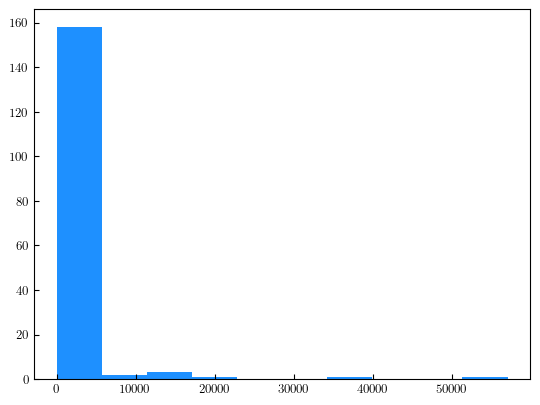

In [87]:
plt.hist(model.neb_res_min)

(0.0, 6000.0)

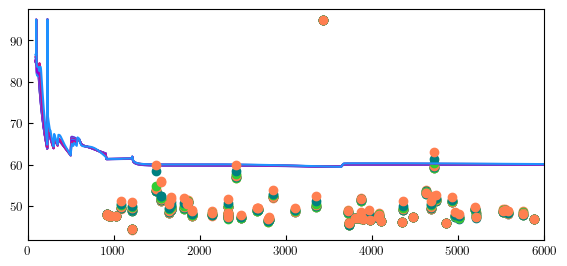

In [ ]:
plt.figure(figsize=(20/3, 3))
for i in range(model.nebem_age.size):
    
    plt.plot(model.csp_lambda, -model.nebem_cont[:, i, 0, 0], label='Continuum')
    plt.plot(model.nebem_line_pos, -model.nebem_line[:, i, 0, 0], 'o', label='Lines')
plt.xlim(0, 6000)

#plt.loglog(model.csp_lambda, spectrum['flux'], label='Continuum')

In [20]:
plt.plot(model.csp_lambda, spec)

NameError: name 'plt' is not defined